# Figure: AD synapse reliability breaks down under sustained stimulation


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from plot_config import (
    get_condition,
    apply_style,
    strip_spines,
    panel_labeler,
    label_panel,
    save_figure,
)

apply_style()

## Configuration

In [2]:
# ============================================================
# CONFIG
# ============================================================

from pathlib import Path

CONTROL_RESULT = Path(
    "/data/hdrive/phd/results/train/control/RSV90C250uM_20_p20hz/result"
)
AD_RESULT = Path(
    "/data/hdrive/phd/results/train/AD/RSV90C750uM_20_p20hz_5xryr/result"
)

RESULTS_ROOT = Path("/data/hdrive/phd/results/train")
TRIALS_ROOT = Path("/data/hdrive/phd/output/train")


def trials_dir_for(result_file: Path) -> Path:
    """Map a `.../results/train/<condition>/result` summary file to its
    per-trial sibling directory under `.../output/train/<condition>/`
    (one s_NNNNN/dat/rel.dat per trial)."""
    return TRIALS_ROOT / result_file.parent.relative_to(RESULTS_ROOT)


# plot_config.CONDITIONS key -> per-trial data directory.
CONDITION_TRIALS = {
    "control": trials_dir_for(CONTROL_RESULT),
    "ad_5x_ryr": trials_dir_for(AD_RESULT),
}
CONDITION_ORDER = ["control", "ad_5x_ryr"]  # draw order == legend order

# 20-pulse, 20 Hz train: pulse k (0-indexed) occupies the window
# [k*PULSE_PERIOD, (k+1)*PULSE_PERIOD) seconds.
N_PULSES = 20
PULSE_PERIOD = 0.05  # s (20 Hz)
T0 = 0.0             # s, start of pulse 1's window

TRIAL_VARIANCE_BINS = np.linspace(0, 3, 41)

# Panel a: P11 vs Pr1 (paired-pulse, VDCC sweep) -- pre-aggregated on the cluster,
# only these small CSVs pulled back locally.
PAIRED_PULSE_DIR = Path("paired_pulse_summary")
SWEEP_VDCC_FILES = {
    "control": PAIRED_PULSE_DIR / "sweep_vdcc_control.csv",
    "ad_5x_ryr": PAIRED_PULSE_DIR / "sweep_vdcc_ad.csv",
}

SWEEP_VDCC_EXCLUDE = {"ad_5x_ryr": {110}}
MIN_TRIALS_SWEEP_POINT = 50  # drop VDCC points with too few valid trials to trust

## Load per-trial release-event data

In [3]:
def load_trial_release_counts(trials_dir, n_pulses=N_PULSES, period=PULSE_PERIOD, t0=T0):
    """Per-trial, per-pulse release counts from every s_NNNNN/dat/rel.dat
    under `trials_dir`. Each rel.dat line is
    `time(s) dx dy dz {synchronous,asynchronous}_release_<site>`; the pulse
    a release belongs to is the time bin it falls in (see CONFIG), and
    synchronous + asynchronous events are combined into one count.

    Returns (trial_ids, counts) where counts has shape (n_trials, n_pulses).
    """
    trial_dirs = sorted(p for p in trials_dir.iterdir() if p.name.startswith("s_"))
    counts = np.zeros((len(trial_dirs), n_pulses), dtype=int)

    for i, trial_dir in enumerate(trial_dirs):
        rel_path = trial_dir / "dat" / "rel.dat"
        if not rel_path.exists() or rel_path.stat().st_size == 0:
            continue
        with open(rel_path) as f:
            for line in f:
                fields = line.split(None, 1)
                if not fields:
                    continue
                pulse = int((float(fields[0]) - t0) // period)
                if 0 <= pulse < n_pulses:
                    counts[i, pulse] += 1

    trial_ids = [p.name for p in trial_dirs]
    return trial_ids, counts


release_counts = {}  # key -> (n_trials, N_PULSES) int array

for key in CONDITION_ORDER:
    ids, counts = load_trial_release_counts(CONDITION_TRIALS[key])
    release_counts[key] = counts
    print(f"{key:12s}  {len(ids)} trials  {counts.sum()} release events")

control       2005 trials  22915 release events
ad_5x_ryr     2005 trials  23126 release events


## Derived statistics

In [4]:
pulses = np.arange(1, N_PULSES + 1)

# Per-pulse mean / SD / CV across trials -- feeds the summary figure's panel c.
pulse_stats = {}
for key in CONDITION_ORDER:
    mat = release_counts[key]
    mean = mat.mean(axis=0)
    sd = mat.std(axis=0, ddof=1)
    pulse_stats[key] = {"mean": mean, "sd": sd, "cv": sd / mean}

# Each trial's own variance across its N_PULSES pulses -- feeds panel e.
trial_variance = {
    key: release_counts[key].var(axis=1, ddof=1) for key in CONDITION_ORDER
}

## Load panel a: P11 vs Pr1 (paired-pulse, VDCC sweep)


In [5]:
def load_sweep_vdcc(key):
    arr = np.genfromtxt(SWEEP_VDCC_FILES[key], delimiter=",", names=True)
    exclude = SWEEP_VDCC_EXCLUDE.get(key, set())
    keep = (
        ~np.isnan(arr["pr1"])
        & ~np.isin(arr["vdcc"], list(exclude))
        & (arr["ntrials"] >= MIN_TRIALS_SWEEP_POINT)
    )
    arr = arr[keep]
    return arr[np.argsort(arr["pr1"])]


sweep_vdcc = {key: load_sweep_vdcc(key) for key in CONDITION_ORDER}
for key in CONDITION_ORDER:
    print(f"{key:12s}  {len(sweep_vdcc[key])} usable VDCC points (P11 + VDCC-influx CV)")

control       47 usable VDCC points (P11 + VDCC-influx CV)
ad_5x_ryr     23 usable VDCC points (P11 + VDCC-influx CV)


## Load panel b: consecutive-pulse coupling P(k,k+1)

The train-protocol analogue of P11 -- P(release@pulse k+1 | release@pulse k), for
each consecutive pulse pair.

In [6]:
train_p_consec = {}

for key in CONDITION_ORDER:
    mat = release_counts[key]
    success = (mat >= 1).astype(float)

    p_consec = np.full(N_PULSES - 1, np.nan)
    for k in range(N_PULSES - 1):
        released_k = success[:, k] > 0
        n_k = released_k.sum()
        if n_k > 0:
            p_consec[k] = (released_k & (success[:, k + 1] > 0)).sum() / n_k
    train_p_consec[key] = p_consec

    print(f"{key:12s}  P(k,k+1) range [{np.nanmin(p_consec):.3f}, {np.nanmax(p_consec):.3f}]")

control       P(k,k+1) range [0.198, 0.660]
ad_5x_ryr     P(k,k+1) range [0.233, 0.824]


## Summary figure: AD synapse reliability breaks down under sustained stimulation


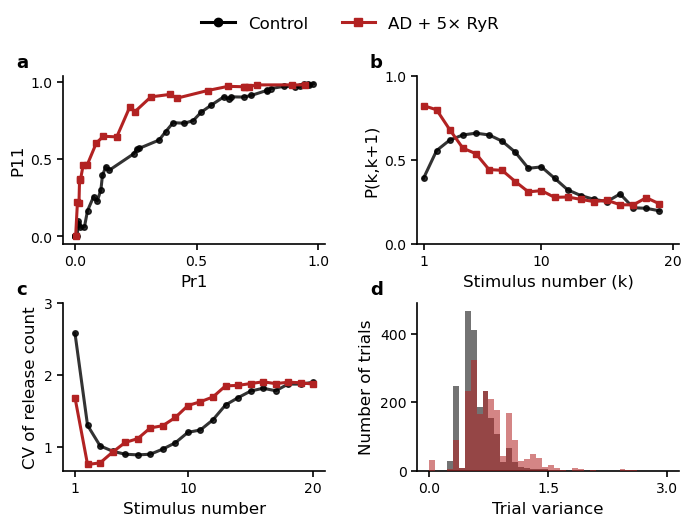

In [55]:
SUMMARY_FIGSIZE = (7, 5)
SUMMARY_FIGURE_PATH = "fig10_sustained_unreliability.png"
SAVE_SUMMARY_FIGURE = True

fig = plt.figure(figsize=SUMMARY_FIGSIZE)
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.35)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])

panel = panel_labeler()

# a. Brief activation, coupling: P11 vs Pr1 (paired-pulse, VDCC sweep)
for key in CONDITION_ORDER:
    cond = get_condition(key)
    d = sweep_vdcc[key]
    ax_a.plot(d["pr1"], d["p11"], color=cond.color, marker=cond.marker,
              alpha=cond.alpha, zorder=cond.zorder, markersize=4)
ax_a.set_xlabel("Pr1")
ax_a.set_ylabel("P11")
ax_a.set_xticks([0.0, 0.5, 1.0])
ax_a.set_yticks([0.0, 0.5, 1.0])
strip_spines(ax_a)
label_panel(ax_a, next(panel))

# b. Sustained activation, coupling: P(k,k+1) vs stimulus number (train)
for key in CONDITION_ORDER:
    cond = get_condition(key)
    ax_b.plot(pulses[:-1], train_p_consec[key], color=cond.color, marker=cond.marker,
              alpha=cond.alpha, zorder=cond.zorder, markersize=4)
ax_b.set_xlabel("Stimulus number (k)")
ax_b.set_ylabel("P(k,k+1)")
ax_b.set_xticks([1, 10, 20])
ax_b.set_xlim(0.5, 20.5)
ax_b.set_yticks([0.0, 0.5, 1.0])
strip_spines(ax_b)
label_panel(ax_b, next(panel))

# c. Sustained activation, variability: CV vs stimulus number (train)
for key in CONDITION_ORDER:
    cond = get_condition(key)
    ax_c.plot(pulses, pulse_stats[key]["cv"], color=cond.color, marker=cond.marker,
              alpha=cond.alpha, zorder=cond.zorder, markersize=4)
ax_c.set_xlabel("Stimulus number")
ax_c.set_ylabel("CV of release count")
ax_c.set_xticks([1, 10, 20])
ax_c.set_yticks([1, 2, 3])
strip_spines(ax_c)
label_panel(ax_c, next(panel))

# d. Erratic whole-trial patterns: trial-variance histogram (train)
for key in CONDITION_ORDER:
    cond = get_condition(key)
    ax_d.hist(trial_variance[key], bins=TRIAL_VARIANCE_BINS, color=cond.color,
              alpha=0.55, zorder=cond.zorder)
ax_d.set_xlabel("Trial variance")
ax_d.set_ylabel("Number of trials")
ax_d.set_xticks([0, 1.5, 3])
ax_d.set_yticks([0, 200, 400])
strip_spines(ax_d)
label_panel(ax_d, next(panel))

legend_handles = [
    Line2D([0], [0], color=get_condition(k).color, marker=get_condition(k).marker,
           label=get_condition(k).label) for k in CONDITION_ORDER
]
fig.legend(handles=legend_handles, loc="upper center", ncol=2, frameon=False,
           bbox_to_anchor=(0.5, 1.03))

fig.subplots_adjust(left=0.09, right=0.97, top=0.88, bottom=0.09, hspace=0.35, wspace=0.35)

if SAVE_SUMMARY_FIGURE:
    save_figure(fig, SUMMARY_FIGURE_PATH)

plt.show()